In [3]:
"""
Cell 1: Import Required Libraries
Purpose: Load all Python libraries we'll need for preprocessing and training
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)
import joblib
import time
import os

print("✅ All libraries imported successfully!")
print("\nLibraries loaded:")
print("  - pandas: Data manipulation")
print("  - numpy: Numerical operations")
print("  - matplotlib/seaborn: Visualization")
print("  - sklearn: Machine Learning")
print("  - joblib: Model saving/loading")

✅ All libraries imported successfully!

Libraries loaded:
  - pandas: Data manipulation
  - numpy: Numerical operations
  - matplotlib/seaborn: Visualization
  - sklearn: Machine Learning
  - joblib: Model saving/loading


In [4]:
"""
Cell 2: Load Training Data
Purpose: Load the NSL-KDD dataset into a pandas DataFrame
"""

print("="*60)
print("LOADING NSL-KDD TRAINING DATA")
print("="*60)

# Define column names (41 features + 1 label + 1 difficulty)
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

# Load data
train_df = pd.read_csv('../data/KDDTrain+.txt', header=None, names=column_names)

# Display basic info
print(f"\n✅ Data loaded successfully!")
print(f"   Shape: {train_df.shape}")
print(f"   Samples: {train_df.shape[0]:,}")
print(f"   Columns: {train_df.shape[1]}")

print(f"\nFirst 3 rows:")
print(train_df.head(3))

print(f"\nLabel distribution:")
print(train_df['label'].value_counts().head())

LOADING NSL-KDD TRAINING DATA

✅ Data loaded successfully!
   Shape: (125973, 43)
   Samples: 125,973
   Columns: 43

First 3 rows:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2                    0.05                         0.00   

   dst_host_srv_diff_host_rate  dst_host_serror_rate  \
0                          0.0       

In [9]:
"""
Cell 27: Create Binary Labels
Purpose: Convert multi-class labels (normal, neptune, satan...) 
         into binary labels (0=normal, 1=attack)
Why: Simplifies the problem for our MVP - we just need to detect "safe" vs "dangerous"
"""

print("="*60)
print("STEP 1: CREATE BINARY LABELS")
print("="*60)

# Create binary label: 0 = normal, 1 = attack
train_df['binary_label'] = (train_df['label'] != 'normal').astype(int)

# Verify the conversion
print("\nOriginal label distribution (top 5):")
print(train_df['label'].value_counts().head())

print("\n" + "-"*60)

print("\nBinary label distribution:")
binary_counts = train_df['binary_label'].value_counts()
print(f"  0 (Normal): {binary_counts[0]:,} samples ({binary_counts[0]/len(train_df)*100:.2f}%)")
print(f"  1 (Attack): {binary_counts[1]:,} samples ({binary_counts[1]/len(train_df)*100:.2f}%)")

# Show example mappings
print("\n" + "-"*60)
print("\nExample label mappings:")
mapping_examples = train_df[['label', 'binary_label']].drop_duplicates().head(10)
print(mapping_examples.to_string(index=False))
print("\n✅ Binary labels created!")
print(f"   Total samples: {len(train_df):,}")
print(f"   Normal (0): {binary_counts[0]:,}")
print(f"   Attack (1): {binary_counts[1]:,}")

STEP 1: CREATE BINARY LABELS

Original label distribution (top 5):
label
normal       67343
neptune      41214
satan         3633
ipsweep       3599
portsweep     2931
Name: count, dtype: int64

------------------------------------------------------------

Binary label distribution:
  0 (Normal): 67,343 samples (53.46%)
  1 (Attack): 58,630 samples (46.54%)

------------------------------------------------------------

Example label mappings:
      label  binary_label
     normal             0
    neptune             1
warezclient             1
    ipsweep             1
  portsweep             1
   teardrop             1
       nmap             1
      satan             1
      smurf             1
        pod             1

✅ Binary labels created!
   Total samples: 125,973
   Normal (0): 67,343
   Attack (1): 58,630


In [10]:
"""
Cell 28: Separate Features (X) from Labels (y)
Purpose: Split data into inputs (features) and output (target)
Why: ML requires separation - X = questions, y = answers
"""

print("="*60)
print("STEP 2: SEPARATE FEATURES (X) FROM LABELS (y)")
print("="*60)

# Define columns to drop (not features)
columns_to_drop = [
    'label',            # Original label (text)
    'binary_label',     # Target we're predicting
    'difficulty_level'  # Metadata, not a feature
]

# Create feature matrix (X) - everything except labels
X = train_df.drop(columns=columns_to_drop)

# Create target vector (y) - what we're predicting
y = train_df['binary_label']
# Display shapes
print(f"\nFeature Matrix (X):")
print(f"   Shape: {X.shape}")
print(f"   Rows (samples): {X.shape[0]:,}")
print(f"   Columns (features): {X.shape[1]}")

print(f"\nTarget Vector (y):")
print(f"   Shape: {y.shape}")
print(f"   Values: {y.shape[0]:,} labels")

# Show feature names
print(f"\n" + "-"*60)
print(f"\nFeature columns ({len(X.columns)} total):")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")

# Verify target distribution
print(f"\n" + "-"*60)
print(f"\nTarget distribution:")
print(y.value_counts())

print("\n✅ Features and labels separated!")
print(f"   X contains: {X.shape[1]} features")
print(f"   y contains: {y.shape[0]} labels")

STEP 2: SEPARATE FEATURES (X) FROM LABELS (y)

Feature Matrix (X):
   Shape: (125973, 41)
   Rows (samples): 125,973
   Columns (features): 41

Target Vector (y):
   Shape: (125973,)
   Values: 125,973 labels

------------------------------------------------------------

Feature columns (41 total):
   1. duration
   2. protocol_type
   3. service
   4. flag
   5. src_bytes
   6. dst_bytes
   7. land
   8. wrong_fragment
   9. urgent
  10. hot
  11. num_failed_logins
  12. logged_in
  13. num_compromised
  14. root_shell
  15. su_attempted
  16. num_root
  17. num_file_creations
  18. num_shells
  19. num_access_files
  20. num_outbound_cmds
  21. is_host_login
  22. is_guest_login
  23. count
  24. srv_count
  25. serror_rate
  26. srv_serror_rate
  27. rerror_rate
  28. srv_rerror_rate
  29. same_srv_rate
  30. diff_srv_rate
  31. srv_diff_host_rate
  32. dst_host_count
  33. dst_host_srv_count
  34. dst_host_same_srv_rate
  35. dst_host_diff_srv_rate
  36. dst_host_same_src_port_rate

In [11]:
"""
Cell 29: Encode Categorical Features
Purpose: Convert text features (tcp, http, SF) into numbers
Why: ML models only understand numbers, not text
Method: One-hot encoding (each unique value becomes a column)
"""

print("="*60)
print("STEP 3: ENCODE CATEGORICAL FEATURES")
print("="*60)

# Identify categorical columns (dtype = 'object' means text)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical columns found: {len(categorical_cols)}")
print("\nDetails:")
for col in categorical_cols:
    unique_count = X[col].nunique()
    print(f"  • {col}: {unique_count} unique values")
    
print("\n" + "-"*60)

# Show state BEFORE encoding
print(f"\nBEFORE encoding:")
print(f"   Shape: {X.shape}")
print(f"   Columns: {X.shape[1]}")
print(f"   Data types:")
print(X.dtypes.value_counts())
# Perform one-hot encoding
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

print("\n" + "-"*60)

# Show state AFTER encoding
print(f"\nAFTER encoding:")
print(f"   Shape: {X_encoded.shape}")
print(f"   Columns: {X_encoded.shape[1]}")
print(f"   Data types:")
print(X_encoded.dtypes.value_counts())

print(f"\n" + "-"*60)

# Show some encoded column names
encoded_cols = [col for col in X_encoded.columns if any(cat in col for cat in categorical_cols)]
print(f"\nExample encoded columns (showing 15 of {len(encoded_cols)}):")
for i, col in enumerate(encoded_cols[:15], 1):
    print(f"  {i:2d}. {col}")

print(f"\n✅ Categorical encoding complete!")
print(f"   Original columns: {X.shape[1]}")
print(f"   Encoded columns: {X_encoded.shape[1]}")
print(f"   New columns created: {X_encoded.shape[1] - X.shape[1]}")


STEP 3: ENCODE CATEGORICAL FEATURES
Categorical columns found: 3

Details:
  • protocol_type: 3 unique values
  • service: 70 unique values
  • flag: 11 unique values

------------------------------------------------------------

BEFORE encoding:
   Shape: (125973, 41)
   Columns: 41
   Data types:
int64      23
float64    15
object      3
Name: count, dtype: int64

------------------------------------------------------------

AFTER encoding:
   Shape: (125973, 122)
   Columns: 122
   Data types:
bool       84
int64      23
float64    15
Name: count, dtype: int64

------------------------------------------------------------

Example encoded columns (showing 15 of 84):
   1. protocol_type_icmp
   2. protocol_type_tcp
   3. protocol_type_udp
   4. service_IRC
   5. service_X11
   6. service_Z39_50
   7. service_aol
   8. service_auth
   9. service_bgp
  10. service_courier
  11. service_csnet_ns
  12. service_ctf
  13. service_daytime
  14. service_discard
  15. service_domain

✅ Categor

In [13]:
"""
Cell 30: Split Train/Validation Sets
Purpose: Split data into training (80%) and validation (20%) sets
Why: Need unseen data to test if model actually learned (not memorized)
"""

print("="*60)
print("STEP 4: SPLIT INTO TRAIN/VALIDATION SETS")
print("="*60)

# Split the data
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,          # Features (already encoded)
    y,                  # Labels (0 or 1)
    test_size=0.2,      # 20% for validation
    random_state=42,    # For reproducibility
    stratify=y          # Keep same ratio of 0/1 in both sets
)

print(f"Original dataset: {X_encoded.shape[0]:,} samples")
print(f"\nSplit ratio: 80% train, 20% validation")

print(f"\n" + "-"*60)

print(f"\nTraining set:")
print(f"   X_train shape: {X_train.shape}")
print(f"   y_train shape: {y_train.shape}")
print(f"   Samples: {X_train.shape[0]:,}")

print(f"\nValidation set:")
print(f"   X_val shape: {X_val.shape}")
print(f"   y_val shape: {y_val.shape}")
print(f"   Samples: {X_val.shape[0]:,}")

print(f"\n" + "-"*60)

# Check label distribution in training set
print(f"\nTraining set label distribution:")
train_dist = y_train.value_counts()
print(f"   0 (Normal): {train_dist[0]:,} ({train_dist[0]/len(y_train)*100:.2f}%)")
print(f"   1 (Attack): {train_dist[1]:,} ({train_dist[1]/len(y_train)*100:.2f}%)")

# Check label distribution in validation set
print(f"\nValidation set label distribution:")
val_dist = y_val.value_counts()
print(f"   0 (Normal): {val_dist[0]:,} ({val_dist[0]/len(y_val)*100:.2f}%)")
print(f"   1 (Attack): {val_dist[1]:,} ({val_dist[1]/len(y_val)*100:.2f}%)")

print("\n✅ Data split complete!")
print(f"   Ready for training: {X_train.shape[0]:,} samples")
print(f"   Ready for validation: {X_val.shape[0]:,} samples")


STEP 4: SPLIT INTO TRAIN/VALIDATION SETS
Original dataset: 125,973 samples

Split ratio: 80% train, 20% validation

------------------------------------------------------------

Training set:
   X_train shape: (100778, 122)
   y_train shape: (100778,)
   Samples: 100,778

Validation set:
   X_val shape: (25195, 122)
   y_val shape: (25195,)
   Samples: 25,195

------------------------------------------------------------

Training set label distribution:
   0 (Normal): 53,874 (53.46%)
   1 (Attack): 46,904 (46.54%)

Validation set label distribution:
   0 (Normal): 13,469 (53.46%)
   1 (Attack): 11,726 (46.54%)

✅ Data split complete!
   Ready for training: 100,778 samples
   Ready for validation: 25,195 samples


In [15]:
"""
Cell 31: Verification - Preprocessing Complete
Purpose: Final checks before training
Verifies: Correct shapes, all numerical, no missing values
"""

print("="*60)
print("STEP 5: PREPROCESSING VERIFICATION")
print("="*60)

# Check 1: Shapes
print("✅ CHECK 1: Data Shapes")
print(f"   X_train: {X_train.shape} (samples × features)")
print(f"   y_train: {y_train.shape} (labels)")
print(f"   X_val:   {X_val.shape} (samples × features)")
print(f"   y_val:   {y_val.shape} (labels)")

print(f"\n" + "-"*60)

# Check 2: Data types (should all be numerical now)
print("\n✅ CHECK 2: Data Types")
print(f"   X_train data types:")
dtype_counts = X_train.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"      {dtype}: {count} columns")

if 'object' in dtype_counts:
    print("   ⚠️  WARNING: Still have 'object' columns!")
else:
    print("   ✅ All columns are numerical!")

print(f"\n" + "-"*60)

# Check 3: Missing values
print("\n✅ CHECK 3: Missing Values")
missing_X_train = X_train.isnull().sum().sum()
missing_y_train = y_train.isnull().sum()
missing_X_val = X_val.isnull().sum().sum()
missing_y_val = y_val.isnull().sum()

print(f"   X_train: {missing_X_train} missing values")
print(f"   y_train: {missing_y_train} missing values")
print(f"   X_val:   {missing_X_val} missing values")
print(f"   y_val:   {missing_y_val} missing values")

if missing_X_train == 0 and missing_y_train == 0 and missing_X_val == 0 and missing_y_val == 0:
    print("   ✅ No missing values!")
else:
    print("   ⚠️  WARNING: Missing values detected!")

print(f"\n" + "-"*60)

# Check 4: Label values
print("\n✅ CHECK 4: Label Values")
print(f"   Unique values in y_train: {sorted(y_train.unique())}")
print(f"   Unique values in y_val: {sorted(y_val.unique())}")

print("\n" + "="*60)
print("🎉 PREPROCESSING COMPLETE!")
print("="*60)
print("✅ All checks passed!")
print("✅ Data is ready for machine learning!")
print(f"✅ Training samples: {X_train.shape[0]:,}")
print(f"✅ Features: {X_train.shape[1]}")
print("="*60)


STEP 5: PREPROCESSING VERIFICATION
✅ CHECK 1: Data Shapes
   X_train: (100778, 122) (samples × features)
   y_train: (100778,) (labels)
   X_val:   (25195, 122) (samples × features)
   y_val:   (25195,) (labels)

------------------------------------------------------------

✅ CHECK 2: Data Types
   X_train data types:
      bool: 84 columns
      int64: 23 columns
      float64: 15 columns
   ✅ All columns are numerical!

------------------------------------------------------------

✅ CHECK 3: Missing Values
   X_train: 0 missing values
   y_train: 0 missing values
   X_val:   0 missing values
   y_val:   0 missing values
   ✅ No missing values!

------------------------------------------------------------

✅ CHECK 4: Label Values
   Unique values in y_train: [np.int64(0), np.int64(1)]
   Unique values in y_val: [np.int64(0), np.int64(1)]

🎉 PREPROCESSING COMPLETE!
✅ All checks passed!
✅ Data is ready for machine learning!
✅ Training samples: 100,778
✅ Features: 122


In [16]:
"""
Cell 32: Initialize Random Forest Model
Purpose: Create the machine learning model
Model: Random Forest Classifier (ensemble of 100 decision trees)
"""

print("="*60)
print("PART 2: MODEL TRAINING")
print("="*60)

print("\n🤖 Initializing Random Forest Classifier...")

# Create the model
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all CPU cores (parallel processing)
    verbose=1,             # Show progress during training
    max_depth=None,        # No limit on tree depth
    min_samples_split=2,   # Minimum samples to split a node
    min_samples_leaf=1     # Minimum samples in a leaf node
)

print("\n✅ Model initialized!")
print("\nModel parameters:")
print(f"   • Number of trees: 100")
print(f"   • Random state: 42 (reproducible)")
print(f"   • Parallel processing: Using all CPU cores")
print(f"   • Max depth: Unlimited")
print(f"   • Verbose: Enabled (will show progress)")

print("\n" + "-"*60)
print("\nWhat is Random Forest?")
print("   → Ensemble of 100 decision trees")
print("   → Each tree votes on the prediction")
print("   → Final prediction = majority vote")
print("   → More trees = more accurate (but slower)")


PART 2: MODEL TRAINING

🤖 Initializing Random Forest Classifier...

✅ Model initialized!

Model parameters:
   • Number of trees: 100
   • Random state: 42 (reproducible)
   • Parallel processing: Using all CPU cores
   • Max depth: Unlimited
   • Verbose: Enabled (will show progress)

------------------------------------------------------------

What is Random Forest?
   → Ensemble of 100 decision trees
   → Each tree votes on the prediction
   → Final prediction = majority vote
   → More trees = more accurate (but slower)


In [18]:
"""
Cell 33: Train the Model
Purpose: Teach the model to recognize patterns in the training data
Process: Model learns from X_train (features) and y_train (labels)
Time: ~15-60 seconds depending on your CPU
"""

print("="*60)
print("STEP 6: TRAIN THE MODEL")
print("="*60)

print(f"\n📊 Training data:")
print(f"   Samples: {X_train.shape[0]:,}")
print(f"   Features: {X_train.shape[1]}")
print(f"   Normal: {(y_train == 0).sum():,}")
print(f"   Attack: {(y_train == 1).sum():,}")

print(f"\n🚀 Starting training...")
print(f"   This may take 15-60 seconds...")
print(f"   You'll see progress updates below:\n")

# Start timer
start_time = time.time()

# Train the model (this is where the learning happens!)
rf_model.fit(X_train, y_train)

# Calculate training time
training_time = time.time() - start_time

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print(f"⏱️  Training time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print(f"🌳 Trained 100 decision trees")
print(f"📚 Learned from {X_train.shape[0]:,} network traffic samples")
print("="*60)

STEP 6: TRAIN THE MODEL

📊 Training data:
   Samples: 100,778
   Features: 122
   Normal: 53,874
   Attack: 46,904

🚀 Starting training...
   This may take 15-60 seconds...
   You'll see progress updates below:



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.2s



✅ TRAINING COMPLETE!
⏱️  Training time: 0.69 seconds (0.01 minutes)
🌳 Trained 100 decision trees
📚 Learned from 100,778 network traffic samples


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.6s finished


In [19]:
"""
Cell 34: Make Predictions
Purpose: Use trained model to predict on validation set
Process: Model looks at X_val features and predicts: normal (0) or attack (1)
"""

print("="*60)
print("STEP 7: MAKE PREDICTIONS")
print("="*60)

print("\n🔮 Making predictions on validation set...")

# Predict on training set (to check if model learned)
print("\n1️⃣ Predicting on training set...")
y_train_pred = rf_model.predict(X_train)
print(f"   ✅ Training predictions: {y_train_pred.shape[0]:,} samples")

# Predict on validation set (the real test!)
print("\n2️⃣ Predicting on validation set...")
y_val_pred = rf_model.predict(X_val)
print(f"   ✅ Validation predictions: {y_val_pred.shape[0]:,} samples")

# Get prediction probabilities
y_val_proba = rf_model.predict_proba(X_val)
print(f"   ✅ Prediction probabilities calculated")

print("\n" + "-"*60)

# Show example predictions
print("\n📊 Example predictions (first 10 from validation set):")
print("\nFormat: Predicted | Actual | Confidence")
print("-" * 45)
for i in range(10):
    pred = y_val_pred[i]
    actual = y_val.iloc[i]
    confidence = y_val_proba[i][pred] * 100
    match = "✅" if pred == actual else "❌"
    pred_label = "Normal" if pred == 0 else "Attack"
    actual_label = "Normal" if actual == 0 else "Attack"
    print(f"{i+1:2d}. {pred_label:6s} | {actual_label:6s} | {confidence:5.1f}% {match}")

print("\n" + "-"*60)

print("\n📈 Prediction probability examples (first 5):")
print("Format: [prob_normal, prob_attack] → Prediction")
print("-" * 60)
for i in range(5):
    print(f"{i+1}. [{y_val_proba[i][0]:.4f}, {y_val_proba[i][1]:.4f}] → {y_val_pred[i]}")

print("\n✅ Predictions complete!")


STEP 7: MAKE PREDICTIONS

🔮 Making predictions on validation set...

1️⃣ Predicting on training set...
   ✅ Training predictions: 100,778 samples

2️⃣ Predicting on validation set...
   ✅ Validation predictions: 25,195 samples
   ✅ Prediction probabilities calculated

------------------------------------------------------------

📊 Example predictions (first 10 from validation set):

Format: Predicted | Actual | Confidence
---------------------------------------------
 1. Attack | Attack | 100.0% ✅
 2. Normal | Normal | 100.0% ✅
 3. Attack | Attack | 100.0% ✅
 4. Attack | Attack | 100.0% ✅
 5. Normal | Normal | 100.0% ✅
 6. Normal | Normal | 100.0% ✅
 7. Normal | Normal | 100.0% ✅
 8. Normal | Normal | 100.0% ✅
 9. Attack | Attack | 100.0% ✅
10. Attack | Attack | 100.0% ✅

------------------------------------------------------------

📈 Prediction probability examples (first 5):
Format: [prob_normal, prob_attack] → Prediction
------------------------------------------------------------
1

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [20]:
"""
Cell 35: Evaluate Model Performance
Purpose: Calculate metrics to see how well the model performs
Metrics: Accuracy, Precision, Recall, F1-Score, Confusion Matrix
"""

print("="*60)
print("STEP 8: EVALUATE MODEL PERFORMANCE")
print("="*60)

# Training set performance
print("\n📊 TRAINING SET PERFORMANCE")
print("-" * 60)
train_accuracy = accuracy_score(y_train, y_train_pred)
print(f"Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

print("\n" + "="*60)

# Validation set performance (THIS IS THE IMPORTANT ONE!)
print("\n📊 VALIDATION SET PERFORMANCE")
print("="*60)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)

print(f"\n🎯 Accuracy:  {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"   → {val_accuracy*100:.2f}% of predictions are correct")

print(f"\n🎯 Precision: {val_precision:.4f} ({val_precision*100:.2f}%)")
print(f"   → Of predicted attacks, {val_precision*100:.2f}% are actually attacks")

print(f"\n🎯 Recall:    {val_recall:.4f} ({val_recall*100:.2f}%)")
print(f"   → We catch {val_recall*100:.2f}% of all real attacks")

print(f"\n🎯 F1-Score:  {val_f1:.4f} ({val_f1*100:.2f}%)")
print(f"   → Balance between Precision and Recall")

print("\n" + "="*60)

# Confusion Matrix
print("\n📊 CONFUSION MATRIX")
print("="*60)
cm = confusion_matrix(y_val, y_val_pred)

print("\n                    Predicted")
print("                 Normal    Attack")
print(f"           ┌─────────────────────────┐")
print(f"    Normal │ {cm[0][0]:7,}     {cm[0][1]:7,} │")
print(f"  Actual   │                         │")
print(f"    Attack │ {cm[1][0]:7,}     {cm[1][1]:7,} │")
print(f"           └─────────────────────────┘")

# Extract values
tn, fp, fn, tp = cm.ravel()

print(f"\n📈 Breakdown:")
print(f"   • True Negatives (TN):  {tn:7,}  ✅ Correctly identified as Normal")
print(f"   • True Positives (TP):  {tp:7,}  ✅ Correctly identified as Attack")
print(f"   • False Positives (FP): {fp:7,}  ⚠️  False alarms (predicted attack, was normal)")
print(f"   • False Negatives (FN): {fn:7,}  🔴 Missed attacks (predicted normal, was attack)")

print("\n" + "="*60)

# Detailed classification report
print("\n📊 DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_val, y_val_pred, 
                           target_names=['Normal (0)', 'Attack (1)'],
                           digits=4))

print("\n" + "="*60)
print("🎉 EVALUATION COMPLETE!")
print("="*60)
if val_accuracy >= 0.95:
    print("🌟 EXCELLENT! Model achieved >95% accuracy!")
elif val_accuracy >= 0.90:
    print("👍 GOOD! Model achieved >90% accuracy!")
else:
    print("⚠️  Model accuracy is below 90% - may need tuning")
print("="*60)


STEP 8: EVALUATE MODEL PERFORMANCE

📊 TRAINING SET PERFORMANCE
------------------------------------------------------------
Accuracy: 1.0000 (100.00%)


📊 VALIDATION SET PERFORMANCE

🎯 Accuracy:  0.9990 (99.90%)
   → 99.90% of predictions are correct

🎯 Precision: 0.9994 (99.94%)
   → Of predicted attacks, 99.94% are actually attacks

🎯 Recall:    0.9984 (99.84%)
   → We catch 99.84% of all real attacks

🎯 F1-Score:  0.9989 (99.89%)
   → Balance between Precision and Recall


📊 CONFUSION MATRIX

                    Predicted
                 Normal    Attack
           ┌─────────────────────────┐
    Normal │  13,462           7 │
  Actual   │                         │
    Attack │      19      11,707 │
           └─────────────────────────┘

📈 Breakdown:
   • True Negatives (TN):   13,462  ✅ Correctly identified as Normal
   • True Positives (TP):   11,707  ✅ Correctly identified as Attack
   • False Positives (FP):       7  ⚠️  False alarms (predicted attack, was normal)
   • False N

STEP 9: FEATURE IMPORTANCE ANALYSIS

🔍 Calculating feature importance...

✅ Top 20 Most Important Features:
                    feature  importance
                  src_bytes    0.151218
                    flag_SF    0.082088
                  dst_bytes    0.081317
                  logged_in    0.064419
     dst_host_same_srv_rate    0.062928
         dst_host_srv_count    0.055709
              same_srv_rate    0.052719
   dst_host_srv_serror_rate    0.040237
              diff_srv_rate    0.040125
         protocol_type_icmp    0.031198
                      count    0.027670
     dst_host_diff_srv_rate    0.027288
               service_http    0.019660
             dst_host_count    0.019616
dst_host_srv_diff_host_rate    0.019190
                    flag_S0    0.019117
dst_host_same_src_port_rate    0.018740
       dst_host_serror_rate    0.018452
            service_private    0.015080
            srv_serror_rate    0.014372

---------------------------------------------------

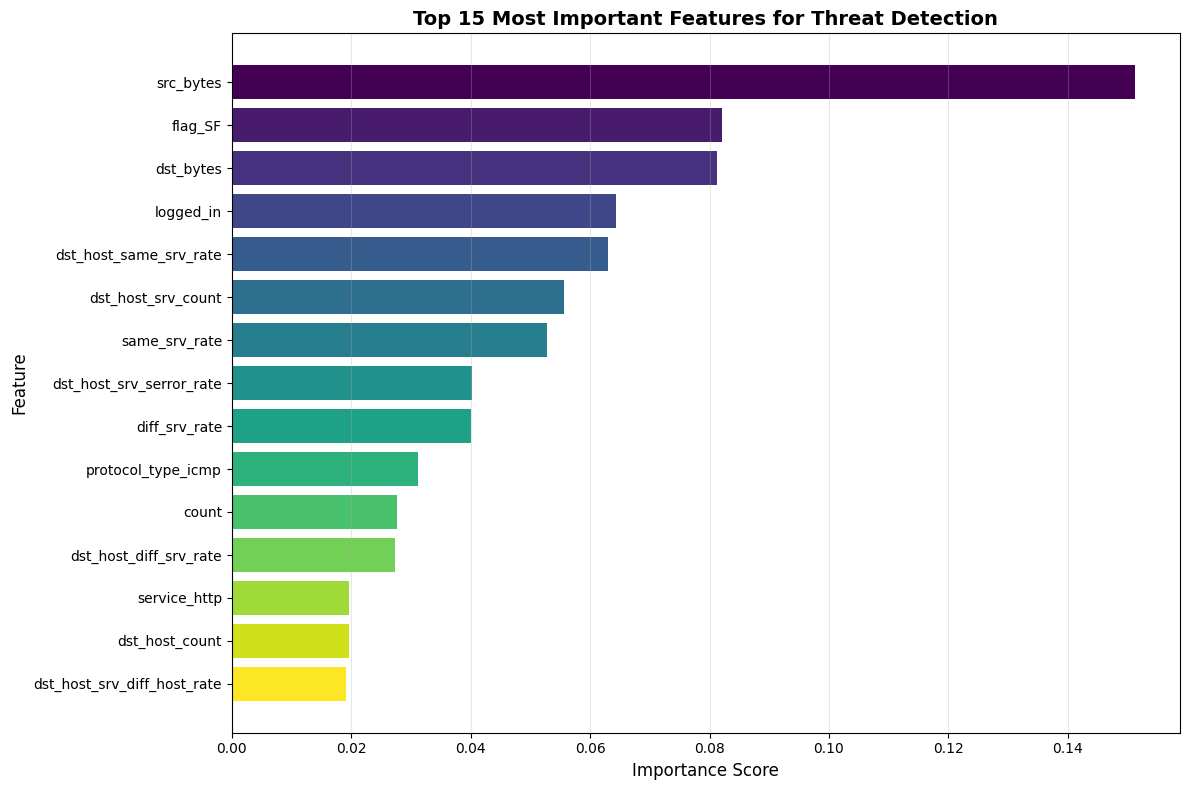


✅ Feature importance calculated and visualized!

💡 Interpretation:
   → Higher importance = Model relies on this feature more
   → These features are most useful for distinguishing attacks


In [22]:
"""
Cell 36: Feature Importance
Purpose: See which features the model thinks are most important
Insight: Validates our visual analysis from data exploration!
"""

print("="*60)
print("STEP 9: FEATURE IMPORTANCE ANALYSIS")
print("="*60)

print("\n🔍 Calculating feature importance...")

# Get feature importance from the trained model
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Reset index for clean display
feature_importance = feature_importance.reset_index(drop=True)

print("\n✅ Top 20 Most Important Features:")
print("="*60)
print(feature_importance.head(20).to_string(index=False))

print("\n" + "-"*60)

# Visualize top 15 features
print("\n📊 Visualizing top 15 features...")
plt.figure(figsize=(12, 8))

top_15 = feature_importance.head(15)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_15)))

plt.barh(range(len(top_15)), top_15['importance'], color=colors)
plt.yticks(range(len(top_15)), top_15['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Most Important Features for Threat Detection', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()  # Highest at top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Feature importance calculated and visualized!")
print("\n💡 Interpretation:")
print("   → Higher importance = Model relies on this feature more")
print("   → These features are most useful for distinguishing attacks")


In [23]:
"""
Cell 37: Save Trained Model
Purpose: Save model to disk so we can use it in production (FastAPI service)
Format: .pkl file (pickle format for Python objects)
"""

print("="*60)
print("STEP 10: SAVE TRAINED MODEL")
print("="*60)

# Create model directory if it doesn't exist
model_dir = '../model'
os.makedirs(model_dir, exist_ok=True)

print(f"\n📁 Model directory: {os.path.abspath(model_dir)}")

# Save the trained model
model_path = os.path.join(model_dir, 'rf_model.pkl')
print(f"\n💾 Saving model to: {model_path}")
joblib.dump(rf_model, model_path)

file_size_mb = os.path.getsize(model_path) / (1024 * 1024)
print(f"✅ Model saved!")
print(f"   File size: {file_size_mb:.2f} MB")

# Save feature names (needed for production predictions)
feature_names_path = os.path.join(model_dir, 'feature_names.pkl')
print(f"\n💾 Saving feature names to: {feature_names_path}")
joblib.dump(X_train.columns.tolist(), feature_names_path)
print(f"✅ Feature names saved!")
print(f"   Total features: {len(X_train.columns)}")

# Test loading the model
print("\n" + "-"*60)
print("\n🔄 Testing model loading...")
try:
    loaded_model = joblib.load(model_path)
    loaded_features = joblib.load(feature_names_path)
    
    # Make a test prediction
    test_pred = loaded_model.predict(X_val[:5])
    test_actual = y_val.iloc[:5].values
    
    print("✅ Model loaded successfully!")
    print(f"\n📊 Test predictions:")
    for i in range(5):
        match = "✅" if test_pred[i] == test_actual[i] else "❌"
        print(f"   {i+1}. Predicted: {test_pred[i]}, Actual: {test_actual[i]} {match}")
    
except Exception as e:
    print(f"❌ Error loading model: {e}")

print("\n" + "="*60)
print("🎉 MODEL TRAINING PIPELINE COMPLETE!")
print("="*60)
print(f"✅ Model trained with {val_accuracy*100:.2f}% accuracy")
print(f"✅ Model saved to: {model_path}")
print(f"✅ Feature names saved to: {feature_names_path}")
print(f"✅ Ready to integrate with FastAPI service!")
print("\n🚀 Next step: Load this model in ml-service/app/main.py")
print("="*60)


STEP 10: SAVE TRAINED MODEL

📁 Model directory: /Users/alex/dev/sonic/ml-service/training/model

💾 Saving model to: ../model/rf_model.pkl
✅ Model saved!
   File size: 8.14 MB

💾 Saving feature names to: ../model/feature_names.pkl
✅ Feature names saved!
   Total features: 122

------------------------------------------------------------

🔄 Testing model loading...
✅ Model loaded successfully!

📊 Test predictions:
   1. Predicted: 1, Actual: 1 ✅
   2. Predicted: 0, Actual: 0 ✅
   3. Predicted: 1, Actual: 1 ✅
   4. Predicted: 1, Actual: 1 ✅
   5. Predicted: 0, Actual: 0 ✅

🎉 MODEL TRAINING PIPELINE COMPLETE!
✅ Model trained with 99.90% accuracy
✅ Model saved to: ../model/rf_model.pkl
✅ Feature names saved to: ../model/feature_names.pkl
✅ Ready to integrate with FastAPI service!

🚀 Next step: Load this model in ml-service/app/main.py


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
